In [1]:
import os
import math
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from utils import Extractor
from circle_fit import taubinSVD
from paddleocr import PaddleOCR

In [2]:
ppocr = PaddleOCR(det_model_dir='ppocr/ch_PP-OCRv3_det_infer',
                rec_model_dir='ppocr/ch_PP-OCRv3_rec_infer',
                cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/16 11:28:56] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='ppocr/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='ppocr/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, fourie

In [3]:
extractor = Extractor()
extractor.load_model()

Straight ring

Text(0.5, 1.0, '(588, 588, 3)')

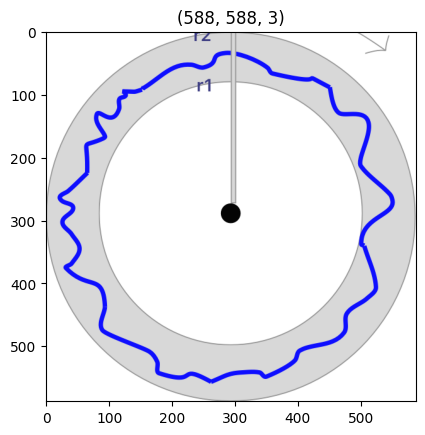

In [4]:
ring = cv2.imread('ring.png')
plt.imshow(ring)
plt.title(ring.shape)

In [5]:
factor = 0.7
size = ring.shape[0]
outer_radius = size // 2
inner_radius = int(factor*outer_radius)
print(f'outer_radius: {outer_radius}')
print(f'inner_radius: {inner_radius}')

outer_radius: 294
inner_radius: 205


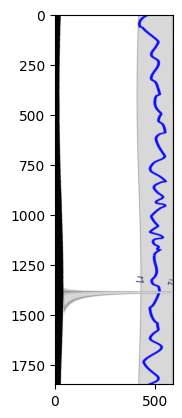

In [6]:
# Unwarp ring
cp = (outer_radius,outer_radius)

warped = cv2.warpPolar(ring, (size, int(size * math.pi)),cp, outer_radius, 0)

plt.imshow(warped)

Text(0.5, 1.0, '(588, 1847, 3)')

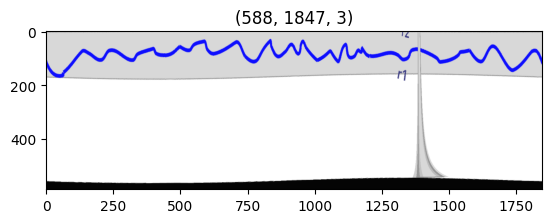

In [7]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(straightened)
plt.title(straightened.shape)

True

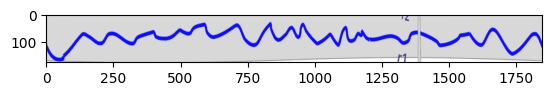

In [8]:
# Crop to ring only
cropped = straightened[: int(straightened.shape[0] * (1 - factor)), :]
plt.imshow(cropped)
cv2.imwrite("straight.png", cropped)

# GG Home Mini

img shape: (3684, 4912, 3)
mask shape: (3104, 4192)


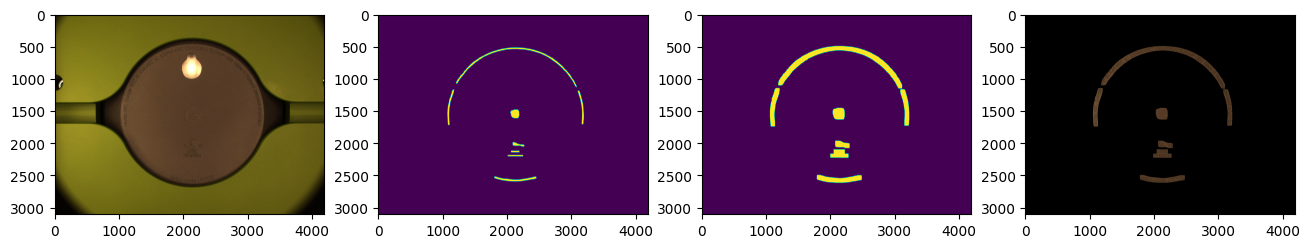

In [89]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img = cv2.imread('snippets/img11.jpg')

mask = extractor.get_mask(img)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))

# and mask
res = cv2.bitwise_and(img_resize,img_resize,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img_resize)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

(1182, 1149)


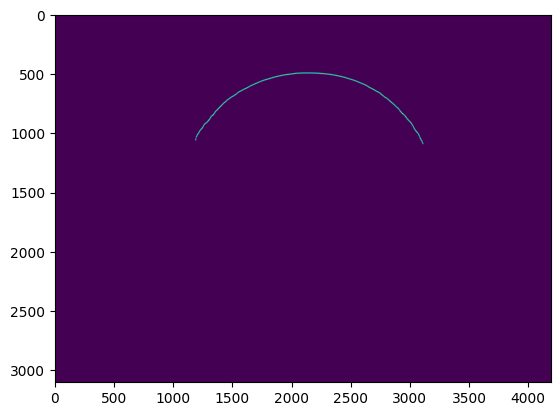

In [90]:
w,h = dilate.shape

v_lines = []
c = []
for i in range(w):
    v_line = dilate[:,i:i+1]
    pos = cv2.findNonZero(v_line) #x,y
    if pos is not None:
        c.append((i,pos[0][0][-1]))
    v_lines.append(v_line)
    
blank = np.zeros_like(dilate)

C= []
c_sub = []
p0 = c[0]
DMAX = 80
for i in range(len(c)):
    p = c[i]
    c_sub.append(p)
    d = cv2.norm(np.array(p),np.array(p0))
    if d > DMAX:
        C.append(c_sub)
        c_sub = []
        print(p0)
    p0 = p
    
C.append(c_sub) # the final c_sub is your circle

L = [len(i) for i in C]
c_sub = C[np.argmax(L)]

blank = np.zeros_like(dilate)
for p in c_sub:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

xc=2136, yc=1584, r=1142, sigma=3.148107121834061


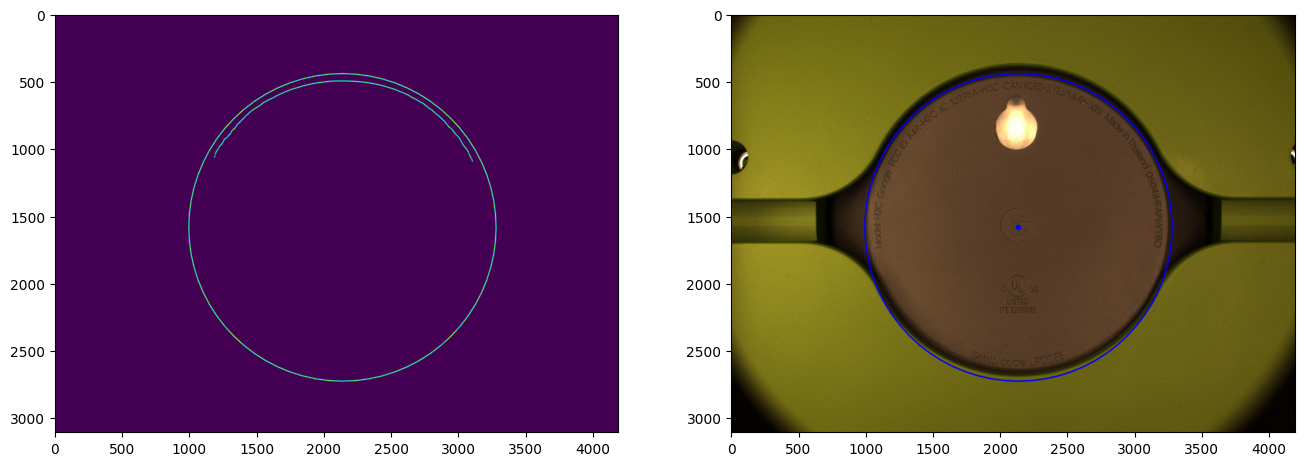

In [91]:
xc, yc, r, sigma = taubinSVD(c_sub)
r = int(r) +50
d = r*2
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

cv2.circle(blank,(int(xc),int(yc)),int(r),(255),6)
cv2.circle(img_resize,(int(xc),int(yc)),20,(0,0,255),-1)
cv2.circle(img_resize,(int(xc),int(yc)),r,(0,0,255),10)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,10))
axes[0].imshow(blank)
axes[1].imshow(img_resize)

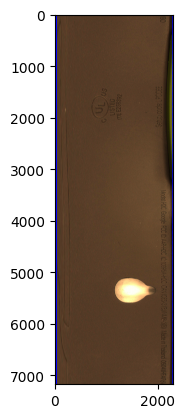

In [92]:
cp = (int(xc),int(yc))
warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
plt.imshow(warped)

[2023/01/16 12:59:13] ppocr DEBUG: dt_boxes num : 1, elapse : 0.17474770545959473
[2023/01/16 12:59:13] ppocr DEBUG: rec_res num  : 1, elapse : 0.1517941951751709
[[[[[894.0, 89.0], [4853.0, 101.0], [4852.0, 268.0], [894.0, 256.0]], ('ModetH2CGoogleFCCDA4R-H2CIC10395A-H2CCANICES-3(B)/NMB-3(B)MadeinThaiand05041HFAP6VYBO', 0.8766564130783081)]]] 



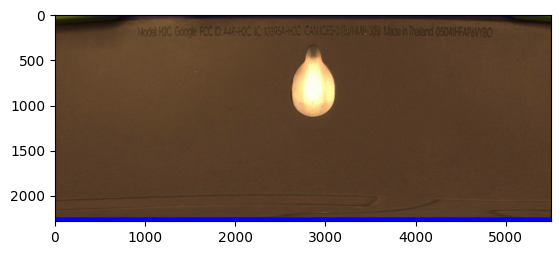

In [93]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
im = np.hstack([straightened,straightened])
im = im[:,2500:8000]
cv2.imwrite('straight.jpg',im)
res1 = ppocr.ocr(im,det=True,rec=True,cls=False)
print(res1,"\n")
plt.imshow(im)

In [94]:
model = None
serial = None

for r in res1[0]:
    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                print('serial: ',s)
                serial = s
                
    print(model.upper(),serial.upper())

serial:  05041hfap6vybo
H2C 05041HFAP6VYBO


In [96]:
def extract(img):
    #dilate
    k = 45
    kernel = np.ones((k,k),np.uint8)

    mask = extractor.get_mask(img)
    dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
    img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))
    
    w,h = dilate.shape
    v_lines = []
    c = []
    C= []
    c_sub = []
    DMAX = 80
    
    for i in range(w):
        v_line = dilate[:,i:i+1]
        pos = cv2.findNonZero(v_line) #x,y
        if pos is not None:
            c.append((i,pos[0][0][-1]))
        v_lines.append(v_line)    
    
    p0 = c[0]
    for i in range(len(c)):
        p = c[i]
        c_sub.append(p)
        d = cv2.norm(np.array(p),np.array(p0))
        if d > DMAX:
            C.append(c_sub)
            c_sub = []
            print(p0)
        p0 = p
        
    C.append(c_sub) # the final c_sub is your circle

    L = [len(i) for i in C]
    c_sub = C[np.argmax(L)]
    
    xc, yc, r, sigma = taubinSVD(c_sub)
    xc = int(xc)
    yc = int(yc)
    r = int(r) +50
    d = r*2
    cp = (xc,yc)
    
    straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
    im = np.hstack([straightened,straightened])
    im = im[:,2500:8000]
    res = ppocr.ocr(im,det=True,rec=True,cls=False)
    return res

(1182, 1151)
[2023/01/16 13:05:13] ppocr DEBUG: dt_boxes num : 1, elapse : 0.1713237762451172
[2023/01/16 13:05:13] ppocr DEBUG: rec_res num  : 1, elapse : 0.1512308120727539
Model:  H2C Serial:  05041HFAP6VYBO


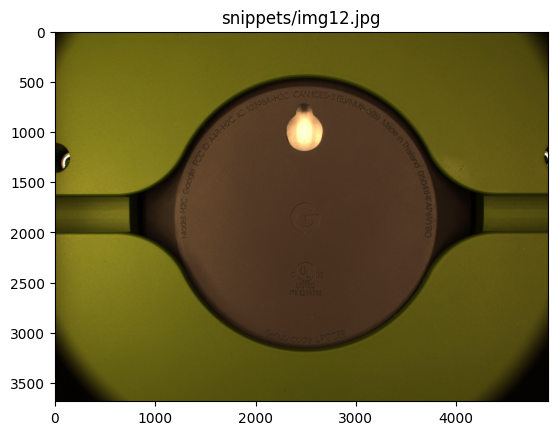

In [117]:
model = None
serial = None

i = random.choice(list(range(2,13)))
img = cv2.imread(f'snippets/img{i}.jpg')
plt.imshow(img)
plt.title(f'snippets/img{i}.jpg')
res = extract(img)

for r in res[0]:
    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                serial = s
                
    print("Model: ",model.upper(),"Serial: ",serial.upper())

# references

[ring-to-a-rectangle](https://stackoverflow.com/questions/71416458/how-to-map-points-from-a-surface-of-2d-ring-to-a-rectangle)

[using-dilation-in-only-one-direction](https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction)

[straightening-contoured-rectangles](https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python)

[How to convert curves in images to lines in Python?](https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python)

[paddleocr](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/paddleocr.py)